In [1]:
from datasets import load_dataset

In [2]:
dataset = load_dataset("rakesh-tirlangi/contras-learning-ai-job-desc-embedding")

README.md:   0%|          | 0.00/582 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.27M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/809 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/102 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['query', 'job_description_pos', 'job_description_neg'],
        num_rows: 809
    })
    validation: Dataset({
        features: ['query', 'job_description_pos', 'job_description_neg'],
        num_rows: 101
    })
    test: Dataset({
        features: ['query', 'job_description_pos', 'job_description_neg'],
        num_rows: 102
    })
})

In [4]:
import pandas as pd

In [5]:
df = dataset["train"].to_pandas()
df.head()

,query,job_description_pos,job_description_neg
0,Data engineering Azure cloud Apache Spark Kafka,Skills:Proven experience in data engineering a...,"requirements, and assist in data structure imp..."
1,"Databricks, Medallion architecture, ETL processes","experience with Databricks, PySpark, SQL, Spar...",experience with a minimum of 0+ years of exper...
2,"Gas Processing, AI Strategy Development, Plant...",experience in AI applications for the Hydrocar...,QualificationsAbility to gather business requi...
3,"Data Analyst ETL Services, Complex Data Analys...","requirements, and integrated management system...",requirements Skills Required: Have Technical D...
4,Data Engineer SQL Snowflake DBT,"experience working with relational databases, ...",experienceCollaborate with other solution and ...


In [6]:
from sentence_transformers import SentenceTransformer

In [7]:
model_name = "sentence-transformers/all-distilroberta-v1"
model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'RobertaModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [9]:
from sentence_transformers.evaluation import TripletEvaluator

In [10]:
evaluator = TripletEvaluator(
    anchors = dataset["validation"]["query"],
    positives = dataset["validation"]["job_description_pos"],
    negatives = dataset["validation"]["job_description_neg"],
    name = "dataset-evaluation",
)
evaluator(model)

{'dataset-evaluation_cosine_accuracy': 0.8811880946159363}

In [11]:
from sentence_transformers.losses import MultipleNegativesRankingLoss
loss = MultipleNegativesRankingLoss(model)

In [13]:
# training args

from sentence_transformers import SentenceTransformerTrainingArguments
from sentence_transformers.training_args import BatchSamplers

batch_size = 32

training_args = SentenceTransformerTrainingArguments(
    output_dir = "models/distilroberta-job-embedding",
    num_train_epochs = 3,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    learning_rate = 2e-5,
    warmup_steps = 0.1,
    batch_sampler = BatchSamplers.NO_DUPLICATES,
    eval_strategy = "steps",
    eval_steps = 100,
    logging_steps = 100
)

In [15]:
from sentence_transformers import SentenceTransformerTrainer

trainer = SentenceTransformerTrainer(
    model = model,
    args = training_args,
    train_dataset = dataset["train"],
    eval_dataset = dataset["validation"],
    loss = loss,
    evaluator = evaluator
)

trainer.train()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=78, training_loss=0.8382761050493289, metrics={'train_runtime': 264.4521, 'train_samples_per_second': 9.177, 'train_steps_per_second': 0.295, 'total_flos': 0.0, 'train_loss': 0.8382761050493289, 'epoch': 3.0})

In [16]:
evaluator_test = TripletEvaluator(
    anchors=dataset["test"]["query"],
    positives=dataset["test"]["job_description_pos"],
    negatives=dataset["test"]["job_description_neg"],
    name="ai-job-test",
)
print("Validation:", evaluator(model))
print("Test:", evaluator_test(model))

Validation: {'dataset-evaluation_cosine_accuracy': 0.9900990128517151}
Test: {'ai-job-test_cosine_accuracy': 1.0}


In [20]:
from huggingface_hub import notebook_login
notebook_login()

In [21]:
model.push_to_hub("rakesh-tirlangi/distilroberta-embedding-job")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...p_tzkqf/model.safetensors:   0%|          |  551kB /  328MB            

'https://huggingface.co/rakesh-tirlangi/distilroberta-embedding-job/commit/217171b6a9020d1d06517e9b8d583784239fd1dd'

In [22]:
from sentence_transformers import SentenceTransformer

base_model = SentenceTransformer("sentence-transformers/all-distilroberta-v1")

finetuned_model = SentenceTransformer("rakesh-tirlangi/distilroberta-embedding-job")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-distilroberta-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

In [23]:
queries = dataset["test"]["query"][:300]
positives = dataset["test"]["job_description_pos"][:300]
negatives = dataset["test"]["job_description_neg"][:300]

labels = ["query"] * len(queries) + ["positive"] * len(positives) + ["negative"] * len(negatives)

texts = queries + positives + negatives

In [24]:
base_embeddings = base_model.encode(texts, show_progress_bar=True)
finetuned_embeddings = finetuned_model.encode(texts, show_progress_bar=True)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [25]:
import umap
import matplotlib.pyplot as plt

def plot_umap(embeddings, labels, title):
    reducer = umap.UMAP(random_state=42)
    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8,6))

    unique_labels = list(set(labels))
    for lab in unique_labels:
        idxs = [i for i, l in enumerate(labels) if l == lab]
        plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=lab, alpha=0.7)

    plt.legend()
    plt.title(title)
    plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


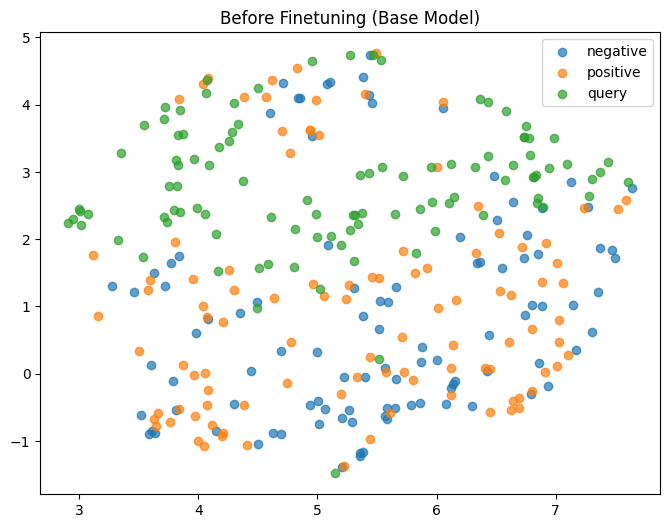

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


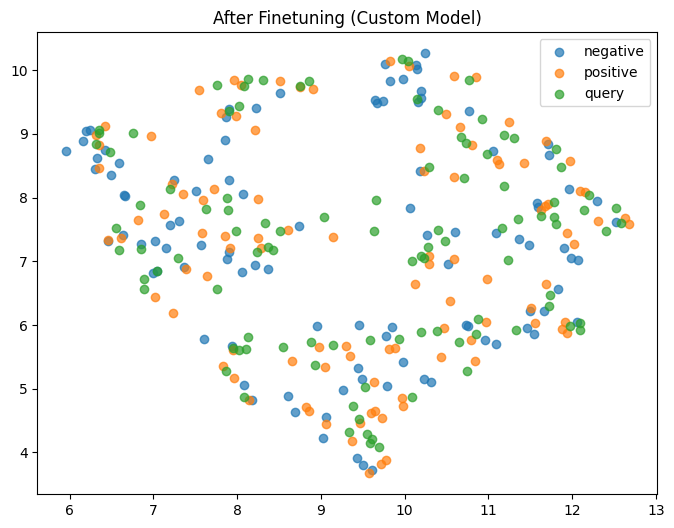

In [26]:
plot_umap(base_embeddings, labels, "Before Finetuning (Base Model)")
plot_umap(finetuned_embeddings, labels, "After Finetuning (Custom Model)")

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

def compute_similarity(model):
    q_emb = model.encode(queries)
    p_emb = model.encode(positives)
    n_emb = model.encode(negatives)

    pos_sim = [cosine_similarity([q], [p])[0][0] for q, p in zip(q_emb, p_emb)]
    neg_sim = [cosine_similarity([q], [n])[0][0] for q, n in zip(q_emb, n_emb)]

    return pos_sim, neg_sim


base_pos, base_neg = compute_similarity(base_model)
fine_pos, fine_neg = compute_similarity(finetuned_model)

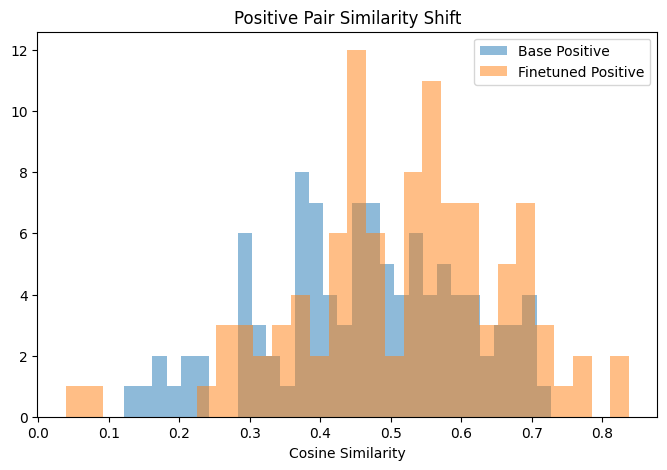

In [28]:
plt.figure(figsize=(8,5))

plt.hist(base_pos, bins=30, alpha=0.5, label="Base Positive")
plt.hist(fine_pos, bins=30, alpha=0.5, label="Finetuned Positive")

plt.title("Positive Pair Similarity Shift")
plt.xlabel("Cosine Similarity")
plt.legend()
plt.show()

In [29]:
def compute_margin(pos, neg):
    return np.mean([p - n for p, n in zip(pos, neg)])

print("Base Margin:", compute_margin(base_pos, base_neg))
print("Finetuned Margin:", compute_margin(fine_pos, fine_neg))

Base Margin: 0.21934886
Finetuned Margin: 0.52335125


In [30]:
import umap
import numpy as np

combined = np.vstack([base_embeddings, finetuned_embeddings])

reducer = umap.UMAP(n_components=2, random_state=42)
reduced = reducer.fit_transform(combined)

n = len(base_embeddings)

base_2d = reduced[:n]
fine_2d = reduced[n:]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [31]:
def interpolate_points(start, end, steps=30):
    return [start + (end - start) * (i / steps) for i in range(steps)]

In [32]:
import plotly.graph_objects as go

frames = []
steps = 30

for i in range(steps):
    interp = np.array([
        base_2d[j] + (fine_2d[j] - base_2d[j]) * (i / steps)
        for j in range(len(base_2d))
    ])

    frame = go.Frame(
        data=[go.Scatter(
            x=interp[:,0],
            y=interp[:,1],
            mode='markers',
            marker=dict(size=6),
        )],
        name=str(i)
    )
    frames.append(frame)

In [33]:
fig = go.Figure(
    data=[go.Scatter(
        x=base_2d[:,0],
        y=base_2d[:,1],
        mode='markers',
        marker=dict(size=6),
    )],
    frames=frames
)

fig.update_layout(
    title="Embedding Space Evolution (Before → After Finetuning)",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play",
             "method": "animate",
             "args": [None, {"frame": {"duration": 100, "redraw": True}}]}
        ]
    }]
)

fig.show()